In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import matplotlib
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_parquet('data/slurm-preprocessed.parquet', columns=['JobID', 'Partition', 'NodeList', 'Start', 'End', 'State', 'ReqTRES'])

In [3]:
target_nodes = sorted([
    "gpu103", "gpu107", "gpu111", "gpu106", "gpu108", "gpu121", 
    "gpu113", "gpu104", "gpu112", "gpu105", "gpu109", "gpu110", 
    "gpu114", "gpu123", "gpu122"
])

gpu_types = {
    "gpu103": "V100", "gpu104": "V100", "gpu105": "V100", "gpu106": "V100",
    "gpu107": "V100", "gpu108": "V100", "gpu109": "V100", "gpu110": "V100",
    "gpu111": "A100", "gpu112": "A100", "gpu113": "A100", "gpu114": "A100 MIG",
    "gpu121": "H100", "gpu122": "Intel Max", "gpu123": "AMD"
}

In [4]:
df['Base_JobID'] = df['JobID'].astype(str).str.split('.').str[0]
valid_reqs = df.dropna(subset=['ReqTRES'])[['Base_JobID', 'ReqTRES']].drop_duplicates('Base_JobID')
req_map = dict(zip(valid_reqs['Base_JobID'], valid_reqs['ReqTRES']))
df['ReqTRES'] = df['ReqTRES'].fillna(df['Base_JobID'].map(req_map))

In [5]:
is_cpu_only = ~df['ReqTRES'].str.contains('gpu', case=False)
cpu_jobs = df[is_cpu_only]
cpu_jobs

,JobID,Partition,NodeList,Start,End,State,ReqTRES,Base_JobID
0,1861200,k2-lowpri,"node[172,179]",2024-12-14 10:00:29,2025-03-07 18:00:53,TIMEOUT,"billing=60,cpu=60,mem=800G,node=1",1861200
1,1861200.batch,k2-lowpri,node172,2024-12-14 10:00:29,2025-03-07 18:00:54,CANCELLED,"billing=60,cpu=60,mem=800G,node=1",1861200
2,2054579,k2-lowpri,node208,2025-02-09 08:34:48,2025-02-15 14:51:17,COMPLETED,"billing=56,cpu=56,mem=900G,node=1",2054579
3,2054580,k2-lowpri,node207,2025-02-09 18:42:04,2025-02-15 22:29:07,COMPLETED,"billing=56,cpu=56,mem=900G,node=1",2054580
4,2054581,k2-lowpri,node163,2025-02-11 04:01:24,2025-02-17 17:31:34,COMPLETED,"billing=56,cpu=56,mem=900G,node=1",2054581
...,...,...,...,...,...,...,...,...
10888396,7598918.batch,k2-living-labs,node214,2026-02-28 23:27:50,2026-02-28 23:34:57,COMPLETED,"billing=32,cpu=32,mem=1031040M,node=1",7598918
10888397,7598927,k2-living-labs,node214,2026-02-28 23:38:50,2026-03-01 00:06:49,COMPLETED,"billing=32,cpu=32,mem=1031040M,node=1",7598927
10888398,7598927.batch,k2-living-labs,node214,2026-02-28 23:38:50,2026-03-01 00:06:49,COMPLETED,"billing=32,cpu=32,mem=1031040M,node=1",7598927
10888399,7598928,k2-living-labs,node215,2026-02-28 23:40:35,2026-03-01 01:42:23,COMPLETED,"billing=32,cpu=32,mem=1031040M,node=1",7598928


In [6]:
df = df[df['NodeList'].isin(target_nodes)].copy()

df['Start'] = pd.to_datetime(df['Start'], errors='coerce')
df['End'] = pd.to_datetime(df['End'], errors='coerce')
df = df.dropna(subset=['Start', 'End'])
df = df[df['End'] > df['Start']]

df['State'] = df['State'].fillna('UNKNOWN')

In [7]:
def merge_intervals(intervals):
    if not intervals: return 0
    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]
    for current in intervals[1:]:
        prev = merged[-1]
        if current[0] <= prev[1]:
            merged[-1] = (prev[0], max(prev[1], current[1]))
        else:
            merged.append(current)
    return sum((end - start).total_seconds() / 3600.0 for start, end in merged)

def generate_stats_report(data_df, total_hours):
    stats_records = []
    
    data_df['ReqTRES'] = data_df['ReqTRES'].fillna('')
    
    for node in target_nodes:
        node_jobs = data_df[data_df['NodeList'] == node]
        
        is_cpu_only = (node_jobs['ReqTRES'] != '') & (~node_jobs['ReqTRES'].str.contains('gpu', case=False, na=False))
        cpu_jobs = node_jobs[is_cpu_only]
        gpu_jobs = node_jobs[~is_cpu_only]
        
        intervals_all = list(zip(node_jobs['Start'], node_jobs['End']))
        active_footprint_hrs = merge_intervals(intervals_all)
        idle_hrs = max(0, total_hours - active_footprint_hrs)
        idle_pct = (idle_hrs / total_hours) * 100 if total_hours > 0 else 0
        
        cpu_intervals = list(zip(cpu_jobs['Start'], cpu_jobs['End']))
        cpu_footprint_hrs = merge_intervals(cpu_intervals)
        cpu_raw_hrs = cpu_jobs['DurationHours'].sum()
        
        comp_jobs = gpu_jobs[gpu_jobs['State'] == 'COMPLETED']
        comp_intervals = list(zip(comp_jobs['Start'], comp_jobs['End']))
        comp_footprint_hrs = merge_intervals(comp_intervals)
        comp_raw_hrs = comp_jobs['DurationHours'].sum()
        
        canc_jobs = gpu_jobs[gpu_jobs['State'].str.startswith('CANCELLED', na=False)]
        canc_intervals = list(zip(canc_jobs['Start'], canc_jobs['End']))
        canc_footprint_hrs = merge_intervals(canc_intervals)
        canc_raw_hrs = canc_jobs['DurationHours'].sum()
        
        fail_jobs = gpu_jobs[(gpu_jobs['State'] != 'COMPLETED') & (~gpu_jobs['State'].str.startswith('CANCELLED', na=False))]
        fail_intervals = list(zip(fail_jobs['Start'], fail_jobs['End']))
        fail_footprint_hrs = merge_intervals(fail_intervals)
        fail_raw_hrs = fail_jobs['DurationHours'].sum()
        
        stats_records.append({
            'Node': node,
            'GPU_Type': gpu_types.get(node, ''),
            'Idle_Hours': round(idle_hrs, 1),
            'Idle_%': round(idle_pct, 2),
            'Merged_Comp_Hrs': round(comp_footprint_hrs, 1),
            'Raw_Comp_Hrs': round(comp_raw_hrs, 1),
            'Merged_Fail_Hrs': round(fail_footprint_hrs, 1),
            'Raw_Fail_Hrs': round(fail_raw_hrs, 1),
            'Merged_Canc_Hrs': round(canc_footprint_hrs, 1),
            'Raw_Canc_Hrs': round(canc_raw_hrs, 1),
            'Merged_CPU_Only_Hrs': round(cpu_footprint_hrs, 1),
            'Raw_CPU_Only_Hrs': round(cpu_raw_hrs, 1),
            'Total_Jobs': len(node_jobs)
        })
    return pd.DataFrame(stats_records).sort_values('Node')

df['DurationHours'] = (df['End'] - df['Start']).dt.total_seconds() / 3600.0

overall_start = df['Start'].min()
overall_end = df['End'].max()
overall_total_hours = (overall_end - overall_start).total_seconds() / 3600.0

overall_stats_df = generate_stats_report(df, overall_total_hours)

In [8]:
start_date = pd.to_datetime('2025-12-15')
end_date = pd.to_datetime('2026-01-31')

df_window = df[(df['Start'] <= end_date) & (df['End'] >= start_date)].copy()
df_window['Start'] = df_window['Start'].clip(lower=start_date)
df_window['End'] = df_window['End'].clip(upper=end_date)
df_window['DurationHours'] = (df_window['End'] - df_window['Start']).dt.total_seconds() / 3600.0

window_total_hours = (end_date - start_date).total_seconds() / 3600.0
window_stats_df = generate_stats_report(df_window, window_total_hours)

node_to_y = {node: i for i, node in enumerate(target_nodes)}

In [9]:
def get_merged_intervals_list(intervals):
    if not intervals: return []
    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]
    for current in intervals[1:]:
        prev = merged[-1]
        if current[0] <= prev[1]:
            merged[-1] = (prev[0], max(prev[1], current[1]))
        else:
            merged.append(current)
    return merged

def get_idle_gaps(merged_active, window_start, window_end):
    idle = []
    current_time = window_start
    for start, end in merged_active:
        if start > current_time:
            idle.append((current_time, start))
        current_time = max(current_time, end)
    if current_time < window_end:
        idle.append((current_time, window_end))
    return idle

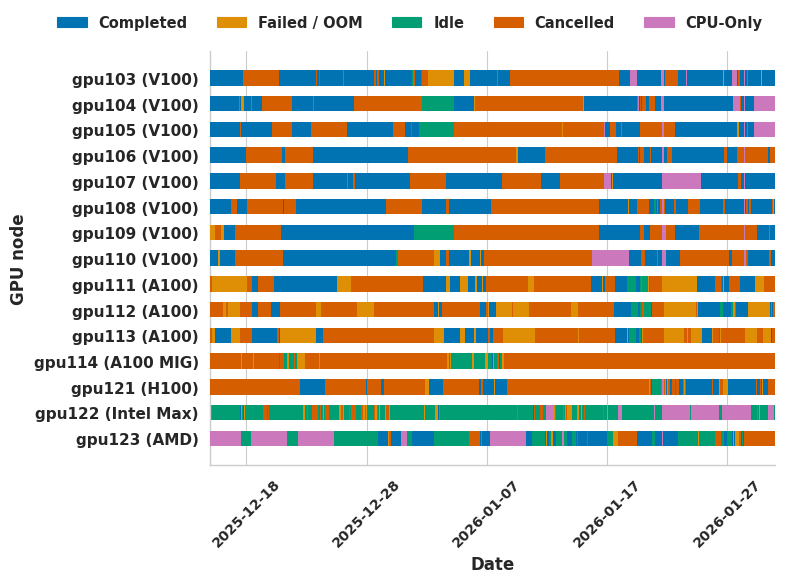

In [10]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

main_palette = sns.color_palette("colorblind")
completed_color = main_palette[0]  # Deep Blue
failed_color = main_palette[1]     # Orange/Yellow
idle_color = main_palette[2]       # Green
cancelled_color = main_palette[3]  # Red/Pink
cpu_only_color = main_palette[4]   # Purple (Anomaly: No GPU Req)

fig, ax = plt.subplots(figsize=(8, 6))

start_num = mdates.date2num(start_date)
duration_days = (end_date - start_date).total_seconds() / (3600.0 * 24.0)

df_window['ReqTRES'] = df_window['ReqTRES'].fillna('')

is_cpu_only = (df_window['ReqTRES'] != '') & (~df_window['ReqTRES'].str.contains('gpu', case=False, na=False))
df_cpu_only = df_window[is_cpu_only]
df_gpu_jobs = df_window[~is_cpu_only] # Only standard jobs go here

for node in target_nodes:
    y = node_to_y[node]
    node_jobs = df_window[df_window['NodeList'] == node]
    
    intervals_all = list(zip(node_jobs['Start'], node_jobs['End']))
    merged_active = get_merged_intervals_list(intervals_all)
    idle_gaps = get_idle_gaps(merged_active, start_date, end_date)
    
    if idle_gaps:
        idle_xranges = [(mdates.date2num(s), (e - s).total_seconds() / (3600.0 * 24.0)) for s, e in idle_gaps]
        ax.broken_barh(idle_xranges, (y - 0.3, 0.6), facecolors=idle_color, alpha=1.0, zorder=2, edgecolors=idle_color, linewidth=0.0, antialiased=False)

df_completed = df_gpu_jobs[df_gpu_jobs['State'] == 'COMPLETED']
df_cancelled = df_gpu_jobs[df_gpu_jobs['State'].str.startswith('CANCELLED', na=False)]
df_failed = df_gpu_jobs[(df_gpu_jobs['State'] != 'COMPLETED') & (~df_gpu_jobs['State'].str.startswith('CANCELLED', na=False))]

for node, group in df_completed.groupby('NodeList'):
    y = node_to_y[node]
    xranges = list(zip(mdates.date2num(group['Start']), group['DurationHours'] / 24.0))
    ax.broken_barh(xranges, (y - 0.3, 0.6), facecolors=completed_color, alpha=1.0, zorder=3, edgecolors=completed_color, linewidth=0.0, antialiased=False)

for node, group in df_failed.groupby('NodeList'):
    y = node_to_y[node]
    xranges = list(zip(mdates.date2num(group['Start']), group['DurationHours'] / 24.0))
    ax.broken_barh(xranges, (y - 0.3, 0.6), facecolors=failed_color, alpha=1.0, zorder=4, edgecolors=failed_color, linewidth=0.0, antialiased=False)

for node, group in df_cancelled.groupby('NodeList'):
    y = node_to_y[node]
    xranges = list(zip(mdates.date2num(group['Start']), group['DurationHours'] / 24.0))
    ax.broken_barh(xranges, (y - 0.3, 0.6), facecolors=cancelled_color, alpha=1.0, zorder=5, edgecolors=cancelled_color, linewidth=0.0, antialiased=False)

for node, group in df_cpu_only.groupby('NodeList'):
    y = node_to_y[node]
    xranges = list(zip(mdates.date2num(group['Start']), group['DurationHours'] / 24.0))
    ax.broken_barh(xranges, (y - 0.3, 0.6), facecolors=cpu_only_color, alpha=1.0, zorder=6, edgecolors=cpu_only_color, linewidth=0.0, antialiased=False)

y_tick_labels = [f"{n} ({gpu_types.get(n, '')})" for n in target_nodes]

ax.set_yticks(range(len(target_nodes)))
ax.set_yticklabels(y_tick_labels, fontsize=11, fontweight='bold')
ax.invert_yaxis()

sns.despine(ax=ax)
ax.set_xlim(start_num, start_num + duration_days)

font_label = {'weight': 'bold', 'size': 12}
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel('Date', fontdict=font_label)
ax.set_ylabel('GPU node', fontdict=font_label)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)
    label.set_rotation(45)

idle_patch = mpatches.Patch(color=idle_color, label='Idle')
comp_patch = mpatches.Patch(color=completed_color, label='Completed')
fail_patch = mpatches.Patch(color=failed_color, label='Failed / OOM')
cancelled_patch = mpatches.Patch(color=cancelled_color, label='Cancelled')
cpu_patch = mpatches.Patch(color=cpu_only_color, label='CPU-Only')

ax.legend(handles=[comp_patch, fail_patch, idle_patch, cancelled_patch, cpu_patch], loc='upper right', bbox_to_anchor=(1.0, 1.12), ncol=5, frameon=False, prop={'weight':'bold'})

fig.subplots_adjust(top=0.82)
plt.tight_layout()

image_path = 'gpu_gantt_window.pdf'

plt.savefig(image_path, bbox_inches='tight', format='pdf')
plt.show() 
plt.close()

In [11]:
print(f"Total Logged Window: {round(overall_total_hours, 1)} Hours per Node")
print(overall_stats_df.to_string(index=False))

print("\n" + "="*130)
print(f"WINDOWED NODE UTILIZATION AND FAILURE REPORT ({start_date.date()} to {end_date.date()})")
print(f"Total Window: {round(window_total_hours, 1)} Hours per Node")
print("="*130)
print(window_stats_df.to_string(index=False))
print("="*130)

md_path = 'gpu_idle_and_failure_stats.md'
with open(md_path, 'w') as f:
    f.write(f"# Overall Node Utilization and Failure Report ({overall_start.date()} to {overall_end.date()})\n")
    f.write(f"**Total Elapsed Window:** {round(overall_total_hours, 1)} Hours per Node\n\n")
    f.write("| Node | GPU Type | Idle % | Idle Hrs | Merged Completed Hrs | Merged Failed Hrs | Merged Cancelled Hrs | Merged CPU-Only Hrs | Raw CPU-Only Hrs |\n")
    f.write("|------|----------|--------|----------|----------------------|-------------------|----------------------|---------------------|------------------|\n")
    for _, row in overall_stats_df.iterrows():
        f.write(f"| {row['Node']} | {row['GPU_Type']} | {row['Idle_%']}% | {row['Idle_Hours']} | {row['Merged_Comp_Hrs']} | {row['Merged_Fail_Hrs']} | {row['Merged_Canc_Hrs']} | {row['Merged_CPU_Only_Hrs']} | {row['Raw_CPU_Only_Hrs']} |\n")
    
    f.write("\n<br>\n\n")    
    
    f.write(f"# Windowed Node Utilization and Failure Report ({start_date.date()} to {end_date.date()})\n")
    f.write(f"**Total Target Window:** {round(window_total_hours, 1)} Hours per Node\n\n")
    f.write("| Node | GPU Type | Idle % | Idle Hrs | Merged Completed Hrs | Merged Failed Hrs | Merged Cancelled Hrs | Merged CPU-Only Hrs | Raw CPU-Only Hrs |\n")
    f.write("|------|----------|--------|----------|----------------------|-------------------|----------------------|---------------------|------------------|\n")
    for _, row in window_stats_df.iterrows():
        f.write(f"| {row['Node']} | {row['GPU_Type']} | {row['Idle_%']}% | {row['Idle_Hours']} | {row['Merged_Comp_Hrs']} | {row['Merged_Fail_Hrs']} | {row['Merged_Canc_Hrs']} | {row['Merged_CPU_Only_Hrs']} | {row['Raw_CPU_Only_Hrs']} |\n")

Total Logged Window: 9540.7 Hours per Node
  Node  GPU_Type  Idle_Hours  Idle_%  Merged_Comp_Hrs  Raw_Comp_Hrs  Merged_Fail_Hrs  Raw_Fail_Hrs  Merged_Canc_Hrs  Raw_Canc_Hrs  Merged_CPU_Only_Hrs  Raw_CPU_Only_Hrs  Total_Jobs
gpu103      V100       190.3    1.99           8276.8       57719.0           5551.8       14472.8           5783.4       14833.1                752.5            5186.7       14094
gpu104      V100       414.6    4.35           8055.1       57209.8           4959.7       12544.1           5469.1       13752.1                511.3            3738.5       11650
gpu105      V100       717.9    7.52           7634.7       53301.7           4568.8       13206.8           4931.7       12446.1                330.4            2540.0        8753
gpu106      V100       826.0    8.66           7289.0       47941.6           4779.9       14219.9           5285.1       13294.2                286.2            1288.4        8639
gpu107      V100       748.2    7.84           7431.